In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('letroso_results.db')


query_algo = """
    SELECT s.session_id, s.student_name, s.login_time, g.opener, g.score 
    FROM algorithm_scores g
    JOIN sessions s ON g.session_id = s.session_id
"""
df_algo = pd.read_sql_query(query_algo, conn)


df_manual = pd.read_sql_query("SELECT player_name, score FROM manual_scores", conn)


def categorize_opener(row):
    if str(row['opener']).strip().lower() == 'centralism':
        return 'Algorithm (centralism)'
    else:
        return 'Algorithm (Other Opener)'

df_algo['Category'] = df_algo.apply(categorize_opener, axis=1)
df_manual['Category'] = 'Manual (centralism)'

print("Data categorized and ready.")

Data categorized and ready.


In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

df_algo_c_table = df_algo[['session_id', 'student_name', 'score', 'opener', 'login_time']].copy()
df_algo_c_table.columns = ['UserID', 'Name', 'Guesses', 'opener', 'Time']

df_manual_table = df_manual[['player_name', 'score']].copy()
df_manual_table.columns = ['Name', 'Guesses']

print("--- TABLE 1: ALGORITHM GAMES (Opener: 'CENTRALISM') ---")
display(df_algo_c_table)

print("\n" + "="*50 + "\n")

#print("--- TABLE 2: MANUAL GAMES (Opener: 'CENTRALISM') ---")
#display(df_manual_table)



--- TABLE 1: ALGORITHM GAMES (Opener: 'CENTRALISM') ---


,UserID,Name,Guesses,opener,Time
0,3,britney spears,3,centralism,2026-03-15 01:25:10
1,3,britney spears,5,bumble,2026-03-15 01:25:10
2,4,makise kurisu,3,centralism,2026-03-15 01:36:23
3,4,makise kurisu,3,centralism,2026-03-15 01:36:23
4,5,datucha,3,centralism,2026-03-15 01:37:58
5,6,hamlet,2,centralism,2026-03-15 03:46:22
6,7,kukaracha,3,centralism,2026-03-15 03:57:13
7,7,kukaracha,2,centralism,2026-03-15 03:57:13
8,8,ovidius,3,centralise,2026-03-15 03:59:27
9,9,ruxi mgeli,3,centralism,2026-03-15 05:14:14


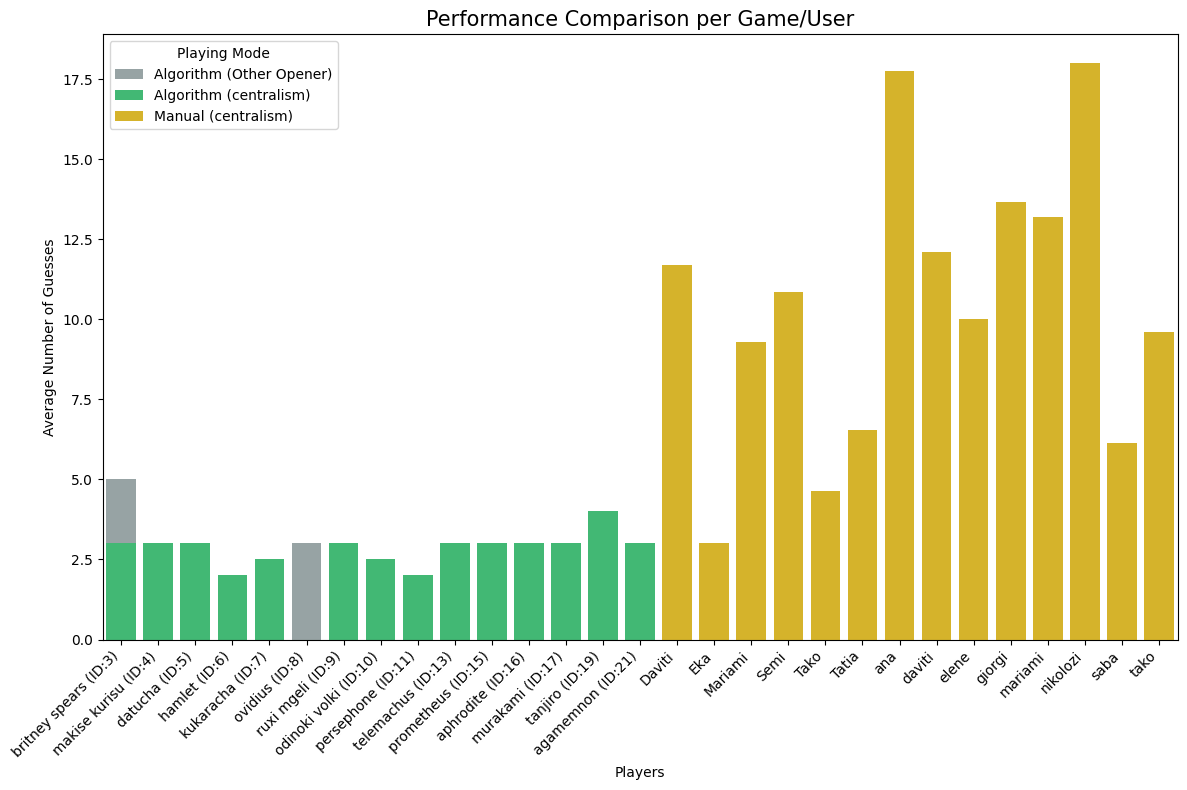

In [3]:
session_avg = df_algo.groupby(['session_id', 'student_name', 'Category'])['score'].mean().reset_index()
session_avg['Players'] = session_avg['student_name'] + " (ID:" + session_avg['session_id'].astype(str) + ")"

manual_avg = df_manual.groupby(['player_name', 'Category'])['score'].mean().reset_index()
manual_avg['Players'] = manual_avg['player_name'] 


plot_df = pd.concat([
    session_avg[['Players', 'score', 'Category']], 
    manual_avg[['Players', 'score', 'Category']]
])

palette_colors = {
    'Algorithm (centralism)': '#2ecc71',  
    'Manual (centralism)': '#f1c40f',      
    'Algorithm (Other Opener)': '#95a5a6'  
}

plt.figure(figsize=(12, 8))

sns.barplot(data=plot_df, x='Players', y='score', hue='Category', palette=palette_colors, dodge=False, errorbar=None)

plt.title('Performance Comparison per Game/User', fontsize=15)
plt.ylabel('Average Number of Guesses')
plt.xticks(rotation=45, ha='right')
plt.legend(title="Playing Mode", loc = 'upper left')
plt.tight_layout()
plt.show()

--- FAIR COMPARISON SUMMARY ---
Manual Average (centralism): 10.39
Algorithm Average (centralism): 2.84
Improvement: 3.65 times less guesses


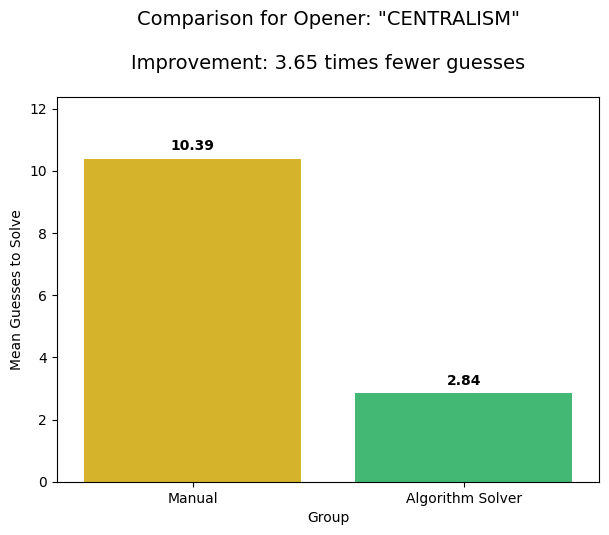

In [4]:
avg_manual = df_manual['score'].mean()
avg_algo_fair = df_algo[df_algo['Category'] == 'Algorithm (centralism)']['score'].mean()
improvement = avg_manual/avg_algo_fair
summary_df = pd.DataFrame({
    'Group': ['Manual', 'Algorithm Solver'],
    'Average Guesses': [avg_manual, avg_algo_fair]
})

plt.figure(figsize=(7, 5))
final_colors = ['#f1c40f', '#2ecc71'] 

ax = sns.barplot(x='Group', y='Average Guesses', data=summary_df, palette=final_colors, hue='Group', legend=False)

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontweight='bold')

plt.title(f'Comparison for Opener: "CENTRALISM"\n\nImprovement: {improvement:.2f} times fewer guesses', 
          fontsize=14, pad=20)
plt.ylabel('Mean Guesses to Solve')
plt.ylim(0, max(avg_manual, avg_algo_fair) + 2)

print(f"--- FAIR COMPARISON SUMMARY ---")
print(f"Manual Average (centralism): {avg_manual:.2f}")
print(f"Algorithm Average (centralism): {avg_algo_fair:.2f}")
print(f"Improvement: {improvement:.2f} times less guesses")

plt.show()
conn.close()